# LIBRARY

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from collections import defaultdict


In [15]:
import numpy as np
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from sklearn.tree._tree import TREE_LEAF
from sklearn.tree import plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [16]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [17]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
import numpy as np

# ── 1. Wrap function as sklearn-compatible class ───────────────────────────────
class DecisionTreeRandomSearch(BaseEstimator, ClassifierMixin):
    def __init__(self, n_iter=400, n_splits=10, random_state=0):
        self.n_iter       = n_iter
        self.n_splits     = n_splits
        self.random_state = random_state

        # these get populated after fit()
        self.best_model_   = None
        self.best_params_  = None
        self.best_score_   = None
        self.y_score_      = None
        self.info_         = None

    def fit(self, X, y):
        param_list = {
            'max_depth':         list(np.arange(2, 50)),
            'min_samples_split': [0.002,0.01, 0.03, 0.05, 0.1, 0.2],
            'min_samples_leaf':  [5, 10, 20, 30, 50, 100, 150],
            'criterion':         ['gini', 'entropy']
        }

        random_search = RandomizedSearchCV(
            DecisionTreeClassifier(),
            param_distributions=param_list,
            cv=KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state),
            scoring='f1_weighted',
            n_jobs=-1,
            refit=True,
            n_iter=self.n_iter,
            random_state=self.random_state,
        )
        random_search.fit(X, y)

        self.best_model_  = random_search.best_estimator_
        self.best_params_ = random_search.best_params_
        self.best_score_  = random_search.best_score_

        self.best_model_.fit(X, y)

        # store full info dict
        self.info_ = {
            'best_params':         self.best_params_,
            'best_cv_score':       self.best_score_,
            'n_features':          self.best_model_.n_features_in_,
            'feature_importances': self.best_model_.feature_importances_,
            'n_classes':           self.best_model_.n_classes_,
            'classes':             self.best_model_.classes_,
            'tree_depth':          self.best_model_.get_depth(),
            'n_leaves':            self.best_model_.get_n_leaves(),
            'cv_results':          random_search.cv_results_,
        }

        print("="*55)
        print("DECISION TREE — TRAINING SUMMARY")
        print("="*55)
        print(f"  Best params   : {self.best_params_}")
        print(f"  Best CV score : {self.best_score_:.4f}")
        print(f"  Tree depth    : {self.info_['tree_depth']}")
        print(f"  Leaves        : {self.info_['n_leaves']}")
        print("="*55)

        return self                          # ← required by sklearn

    def predict(self, X):
        return self.best_model_.predict(X)

    def predict_proba(self, X):
        self.y_score_ = self.best_model_.predict_proba(X)
        return self.y_score_




In [18]:
def train_decision_tree(X_train, y_train, X_test,
                        n_iter=400, n_splits=10, random_state=0):

    # ── 1. Search space ───────────────────────────────────────────────────────
    param_list = {
        'max_depth':         list(np.arange(2, 50)),
        'min_samples_split': [0.002,0.01, 0.03, 0.05, 0.1, 0.2],
        'min_samples_leaf':  [5, 10, 20, 30, 50, 100, 150],
        'criterion':         ['gini', 'entropy']
    }

    # ── 2. Random search ──────────────────────────────────────────────────────
    random_search = RandomizedSearchCV(
        DecisionTreeClassifier(),
        param_distributions=param_list,
        cv=KFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring='f1_weighted',
        n_jobs=-1,
        refit=True,
        n_iter=n_iter,
        random_state=random_state,
    )
    random_search.fit(X_train, y_train)

    # ── 3. Best model ─────────────────────────────────────────────────────────
    best_model = random_search.best_estimator_
    best_model.fit(X_train, y_train)

    # ── 4. Predict ────────────────────────────────────────────────────────────
    y_pred  = best_model.predict(X_test)
    y_score = best_model.predict_proba(X_test)   # ← shape (n_samples, n_classes)

    # ── 5. Collect all attributes ─────────────────────────────────────────────
    info = {
        # best model and params
        'best_model':           best_model,
        'best_params':          random_search.best_params_,
        'best_cv_score':        random_search.best_score_,

        # tree structure
        'n_features':           best_model.n_features_in_,
        'feature_importances':  best_model.feature_importances_,
        'n_classes':            best_model.n_classes_,
        'classes':              best_model.classes_,
        'tree_depth':           best_model.get_depth(),
        'n_leaves':             best_model.get_n_leaves(),

        # search details
        'n_iter':               n_iter,
        'n_splits':             n_splits,
        'cv_results':           random_search.cv_results_,
    }

    # ── 6. Print summary ──────────────────────────────────────────────────────
    print("="*55)
    print("DECISION TREE — TRAINING SUMMARY")
    print("="*55)
    print(f"  Best params       : {info['best_params']}")
    print(f"  Best CV score     : {info['best_cv_score']:.4f}")
    print(f"  Tree depth        : {info['tree_depth']}")
    print(f"  Number of leaves  : {info['n_leaves']}")
    print(f"  Features used     : {info['n_features']}")
    print(f"  Classes           : {info['classes']}")
    print(f"  y_score shape     : {y_score.shape}")   # (n_samples, n_classes)
    print("="*55)

    return y_pred, y_score, info          # ← added y_score here


# READ DATAFRAME

In [19]:
file_path = "../1.DATASET/CMI_FINAL_OD.csv"
df=pd.read_csv(file_path)

In [20]:
df

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
0,0,5,0,16.877316,46.000,50.800000,82.152821,4.611111,17.883041,6.500000,2.0,2.668550,1492.000000,41.586230,9.213770,1.0,19.541300,32.690900,2.0
1,1,9,0,14.035590,48.000,46.000000,90.666667,8.000000,18.204545,11.000000,2.0,2.579490,1498.650000,42.029150,3.970850,1.0,15.410700,27.055200,0.0
2,2,10,1,16.648696,56.500,75.600000,82.333333,27.000000,12.450000,10.000000,3.0,3.389932,1796.890000,59.788250,15.811750,2.0,25.634700,42.380000,0.0
3,3,9,0,18.292347,56.000,81.600000,79.000000,23.000000,18.204545,7.000000,3.0,3.841910,1923.440000,62.775700,18.824300,2.0,26.479800,45.996600,1.0
4,4,18,1,17.937682,54.626,76.139461,90.152104,12.000000,26.463732,8.003205,3.0,12.054014,2652.510000,60.327711,15.811750,2.0,29.912400,42.380000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8377,8455,7,1,16.130585,46.070,48.700252,81.861037,6.500000,18.075000,7.000000,1.0,2.625946,1490.847845,45.526276,3.173977,1.0,18.024600,31.583004,0.0
8378,8456,10,1,17.300000,56.130,77.531978,79.833333,8.500000,13.575000,5.000000,3.0,4.987853,1678.330810,69.880763,7.651215,1.0,22.983200,36.475662,1.0
8379,8457,10,1,40.937571,49.560,143.030726,82.166667,21.500000,16.840263,9.500000,4.0,3.990512,1547.346725,107.979706,35.051020,2.0,31.594712,35.106855,0.0
8380,8458,15,1,22.500000,63.790,130.236404,88.395702,10.000000,26.417470,10.500000,2.0,4.967841,1674.735823,103.517750,26.718654,2.0,46.467581,57.530686,2.0


In [21]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']
X = df[attributes].values
y = np.array(df['sii'])


# Data Preparation

In [22]:
X.shape

(8382, 17)

In [23]:
np.unique(y, return_counts=True)

(array([0., 1., 2., 3.]), array([5794, 1567,  936,   85], dtype=int64))

In [24]:
Counter(y)


Counter({0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85})

In [25]:
ctr = Counter(y)
ctr

Counter({0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85})

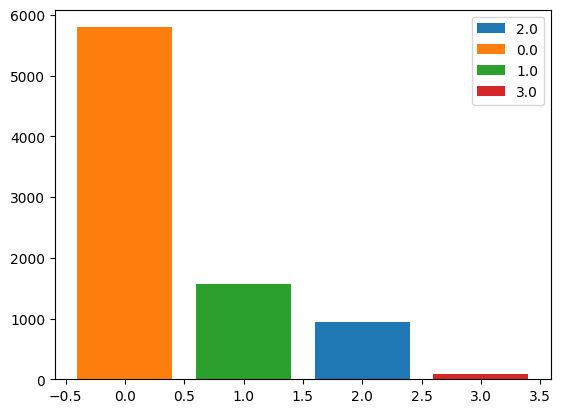

In [26]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange','tab:green','tab:red'])
plt.legend()
plt.show()

## Data Partitioning

In [27]:
from sklearn.model_selection import train_test_split, cross_val_score 

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

In [29]:
X_train.shape

(5867, 17)

In [30]:
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([0., 1., 2., 3.]), array([4056, 1097,  655,   59], dtype=int64)),
 (array([0., 1., 2., 3.]), array([1738,  470,  281,   26], dtype=int64)))

In [31]:
np.max(np.unique(y_train, return_counts=True)[1])/len(X_train)

0.6913243565706494

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## Classification

In [107]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
from scikitplot.metrics import plot_roc

In [34]:
from sklearn.tree import DecisionTreeClassifier

In [35]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['gini', 'entropy']
}

dt_cl_sii = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=0.002, min_samples_leaf=1)

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_list,
    cv=KFold(n_splits=10, shuffle=True, random_state=0),
    scoring='f1_weighted',
    n_jobs=-1,
    refit=True,
    n_iter=400,
)

random_search.fit(X_train, y_train)
dt_cl_sii = random_search.best_estimator_

In [36]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 20, 'max_depth': 14, 'criterion': 'entropy'} 0.5897913694064455


In [108]:
#dt_cl_sii = random_search.best_estimator_
dt_cl_sii = DecisionTreeClassifier()
dt_cl_sii.fit(X_train, y_train)
y_pred0 = dt_cl_sii.predict(X_test)

In [109]:
print('Accuracy %s' % accuracy_score(y_test, y_pred0))
print('F1-score %s' % f1_score(y_test, y_pred0, average=None))
print(classification_report(y_test, y_pred0))

Accuracy 0.5506958250497018
F1-score [0.71003501 0.23430962 0.18487395 0.03921569]
              precision    recall  f1-score   support

         0.0       0.72      0.70      0.71      1738
         1.0       0.23      0.24      0.23       470
         2.0       0.18      0.20      0.18       281
         3.0       0.04      0.04      0.04        26

    accuracy                           0.55      2515
   macro avg       0.29      0.29      0.29      2515
weighted avg       0.56      0.55      0.56      2515



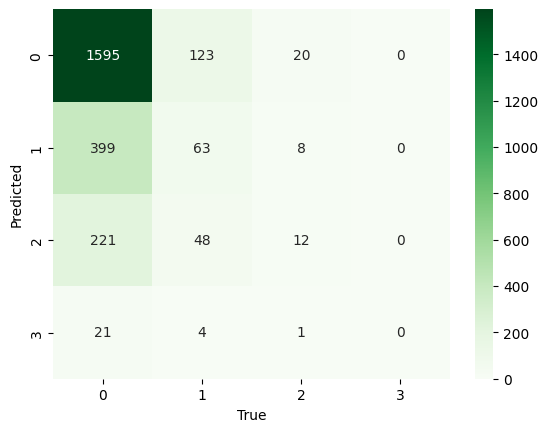

In [39]:
cf = confusion_matrix(y_test, y_pred0)
sns.heatmap(cf, annot=True, cmap="Greens",fmt='g')
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

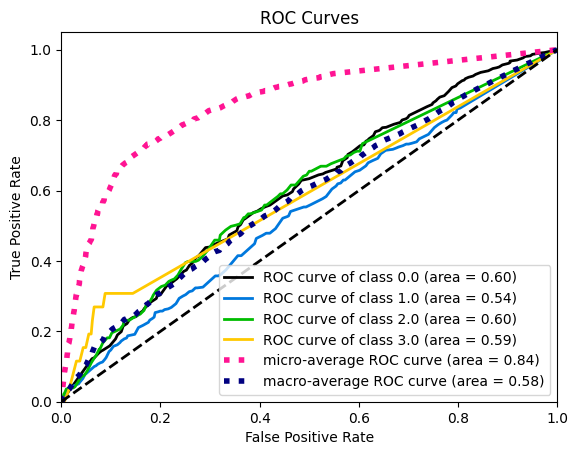

In [40]:
y_score = dt_cl_sii.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

## PCA

In [41]:
from sklearn.decomposition import PCA

In [42]:
def plot_pca(X_pca, y_train):
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolor='k', alpha=0.7)
    plt.show()

In [43]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_train)
print(X_train.shape, X_pca.shape)

(5867, 17) (5867, 2)


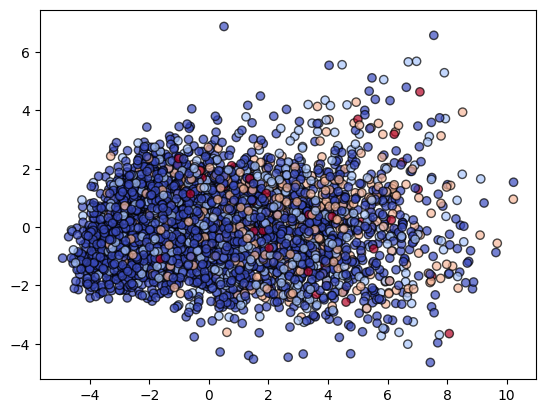

In [44]:
plot_pca(X_pca, y_train)

# Oversampling

In [45]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN

### RandomOverSampler

In [46]:
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1.0: 4056, 0.0: 4056, 2.0: 4056, 3.0: 4056})


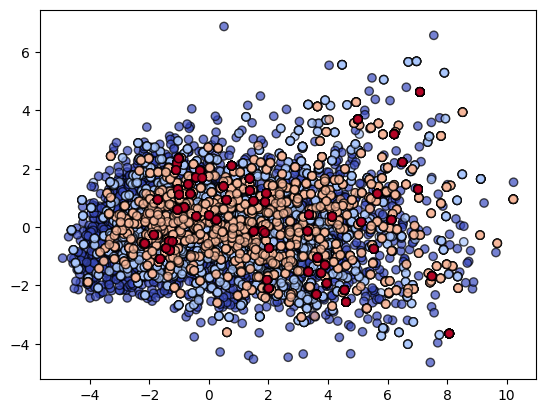

In [47]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [48]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['feature_importances'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 41, 'criterion': 'entropy'}
  Best CV score     : 0.7861
  Tree depth        : 22
  Number of leaves  : 698
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 41, 'criterion': 'entropy'}
[0.07482165 0.01082918 0.07282329 0.12686433 0.06723944 0.05321094
 0.06181913 0.07563295 0.03592658 0.02116476 0.09988746 0.07747444
 0.03762362 0.07039973 0.01033504 0.03846581 0.06548165]
0.7861423172808343


Accuracy 0.4608349900596421
F1-score [0.62660944 0.22060164 0.21153846 0.02777778]
              precision    recall  f1-score   support

         0.0       0.74      0.55      0.63      1738
         1.0       0.19      0.26      0.22       470
         2.0       0.16      0.31      0.21       281
         3.0       0.02      0.04      0.03        26

    accuracy                           0.46      2515
   macro avg       0.28      0.29      0.27      2515
weighted avg       0.56      0.46      0.50      2515



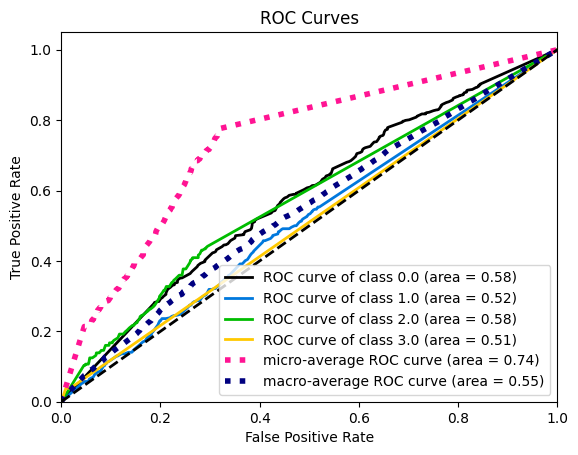

In [49]:
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

plot_roc(y_test, y_score)
plt.show()



### SMOTE

In [50]:

sm = SMOTE(random_state=42, sampling_strategy={1:2500,2:2000,3:1500})
X_res, y_res = sm.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0.0: 4056, 1.0: 2500, 2.0: 2000, 3.0: 1500})


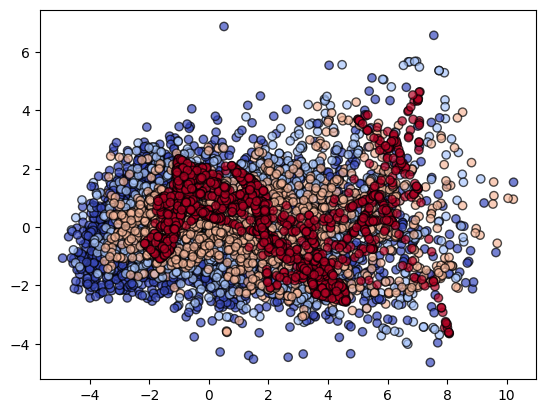

In [51]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [52]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 36, 'criterion': 'entropy'}
  Best CV score     : 0.6226
  Tree depth        : 23
  Number of leaves  : 751
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 36, 'criterion': 'entropy'}
0.6226311202715296


Accuracy 0.5407554671968191
F1-score [0.7108116  0.20449898 0.15706806 0.06060606]
              precision    recall  f1-score   support

         0.0       0.72      0.70      0.71      1738
         1.0       0.20      0.21      0.20       470
         2.0       0.15      0.16      0.16       281
         3.0       0.05      0.08      0.06        26

    accuracy                           0.54      2515
   macro avg       0.28      0.29      0.28      2515
weighted avg       0.55      0.54      0.55      2515



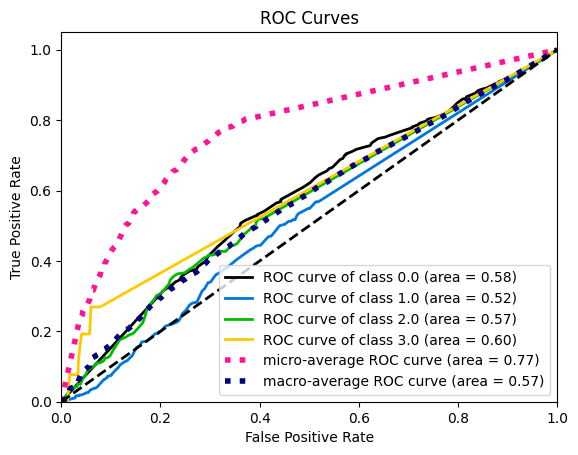

In [53]:
# predict
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()


### ADASYN

In [54]:
ada = ADASYN(random_state=42,sampling_strategy={1:2500,2:2000,3:1500})
X_res, y_res = ada.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0.0: 4056, 1.0: 2560, 2.0: 1828, 3.0: 1514})


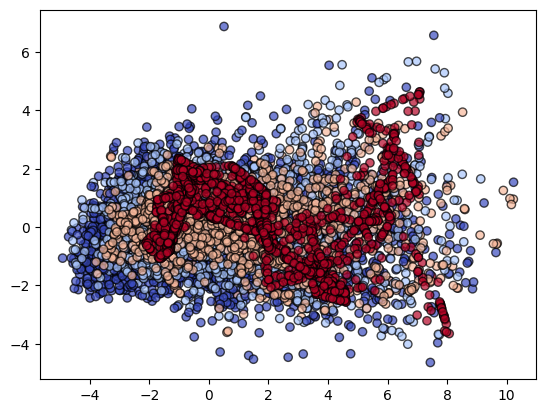

In [55]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [56]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 49, 'criterion': 'gini'}
  Best CV score     : 0.5977
  Tree depth        : 22
  Number of leaves  : 777
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 49, 'criterion': 'gini'}
0.5977341788364964


Accuracy 0.5681908548707754
F1-score [0.72967538 0.2371134  0.17165669 0.02564103]
              precision    recall  f1-score   support

         0.0       0.73      0.73      0.73      1738
         1.0       0.23      0.24      0.24       470
         2.0       0.20      0.15      0.17       281
         3.0       0.02      0.04      0.03        26

    accuracy                           0.57      2515
   macro avg       0.29      0.29      0.29      2515
weighted avg       0.57      0.57      0.57      2515



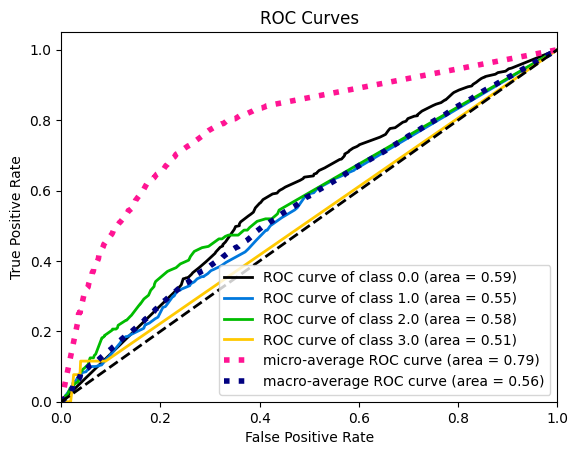

In [57]:
# predict
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()


# Undersampling

In [58]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import CondensedNearestNeighbour
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import EditedNearestNeighbours

### RandomUnderSampler

In [59]:
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0.0: 59, 1.0: 59, 2.0: 59, 3.0: 59})


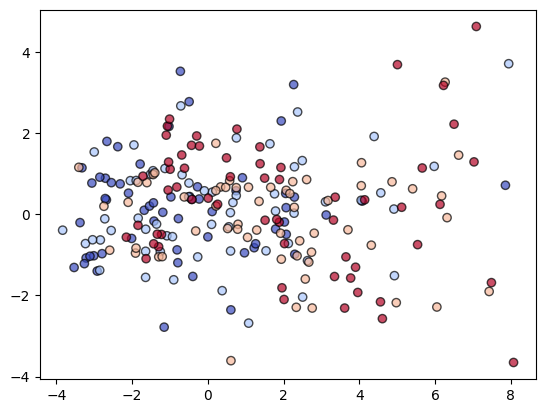

In [60]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [61]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.2, 'min_samples_leaf': 10, 'max_depth': 24, 'criterion': 'gini'}
  Best CV score     : 0.3779
  Tree depth        : 6
  Number of leaves  : 9
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.2, 'min_samples_leaf': 10, 'max_depth': 24, 'criterion': 'gini'}
0.37788591628778734


Accuracy 0.38330019880715704
F1-score [0.52975048 0.23875715 0.25177665 0.03686636]
              precision    recall  f1-score   support

         0.0       0.80      0.40      0.53      1738
         1.0       0.19      0.31      0.24       470
         2.0       0.18      0.44      0.25       281
         3.0       0.02      0.15      0.04        26

    accuracy                           0.38      2515
   macro avg       0.30      0.33      0.26      2515
weighted avg       0.61      0.38      0.44      2515



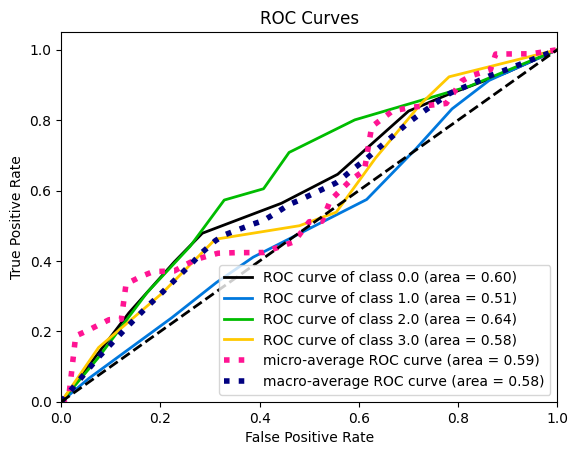

In [62]:
# predict
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()


### CondensedNearestNeighbour

In [63]:
import warnings
warnings.simplefilter("ignore")

In [64]:
cnn = CondensedNearestNeighbour(random_state=42, n_jobs=10)
X_res, y_res = cnn.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0.0: 395, 1.0: 245, 2.0: 207, 3.0: 59})


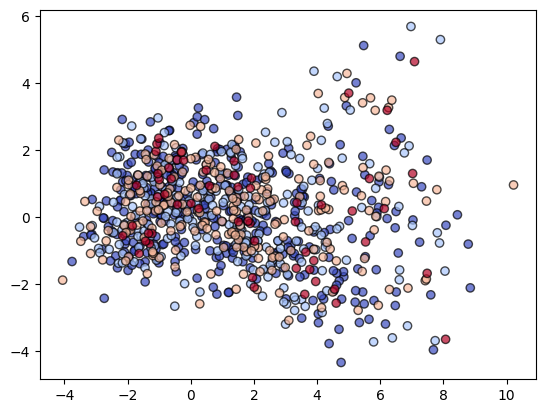

In [65]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [66]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.03, 'min_samples_leaf': 5, 'max_depth': 22, 'criterion': 'gini'}
  Best CV score     : 0.3606
  Tree depth        : 17
  Number of leaves  : 55
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.03, 'min_samples_leaf': 5, 'max_depth': 22, 'criterion': 'gini'}
0.36059944088168566


Accuracy 0.447713717693837
F1-score [0.62062257 0.18892508 0.16416416 0.        ]
              precision    recall  f1-score   support

         0.0       0.71      0.55      0.62      1738
         1.0       0.19      0.19      0.19       470
         2.0       0.11      0.29      0.16       281
         3.0       0.00      0.00      0.00        26

    accuracy                           0.45      2515
   macro avg       0.25      0.26      0.24      2515
weighted avg       0.54      0.45      0.48      2515



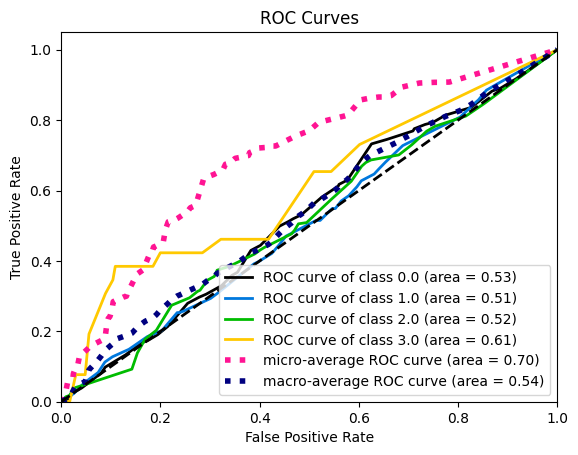

In [67]:
# predict
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()



### Tomek Links

In [68]:
tl = TomekLinks(sampling_strategy='majority')
X_res, y_res = tl.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0.0: 3640, 1.0: 1097, 2.0: 655, 3.0: 59})


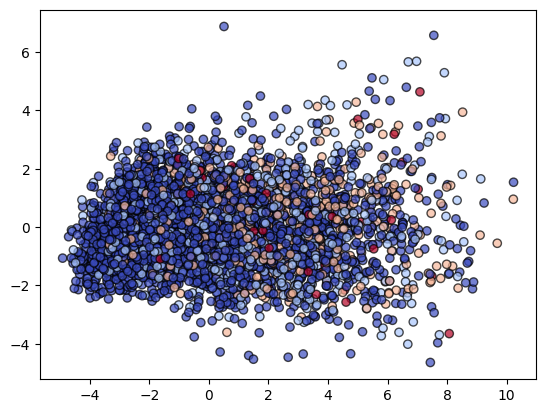

In [69]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [70]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.01, 'min_samples_leaf': 20, 'max_depth': 35, 'criterion': 'entropy'}
  Best CV score     : 0.5736
  Tree depth        : 18
  Number of leaves  : 160
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.01, 'min_samples_leaf': 20, 'max_depth': 35, 'criterion': 'entropy'}
0.5736331385732715


Accuracy 0.6401590457256461
F1-score [0.78584345 0.18276762 0.10354223 0.        ]
              precision    recall  f1-score   support

         0.0       0.71      0.88      0.79      1738
         1.0       0.24      0.15      0.18       470
         2.0       0.22      0.07      0.10       281
         3.0       0.00      0.00      0.00        26

    accuracy                           0.64      2515
   macro avg       0.29      0.27      0.27      2515
weighted avg       0.56      0.64      0.59      2515



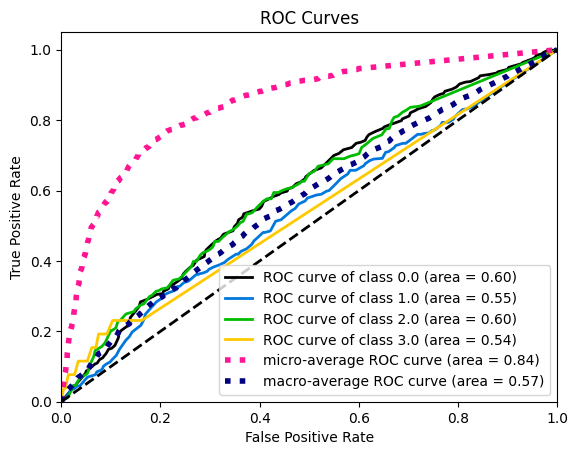

In [71]:
# predict
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()



### Edited Nearest Neighbors

In [72]:
enn = EditedNearestNeighbours(sampling_strategy='majority')
X_res, y_res = enn.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0.0: 1702, 1.0: 1097, 2.0: 655, 3.0: 59})


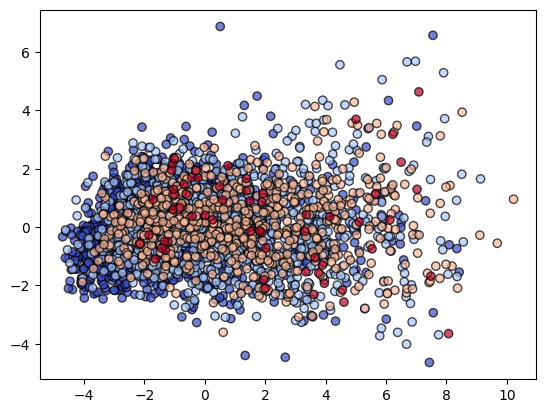

In [73]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [74]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.03, 'min_samples_leaf': 5, 'max_depth': 6, 'criterion': 'gini'}
  Best CV score     : 0.5451
  Tree depth        : 6
  Number of leaves  : 32
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.03, 'min_samples_leaf': 5, 'max_depth': 6, 'criterion': 'gini'}
0.5450642107326376


Accuracy 0.553479125248509
F1-score [0.71140517 0.31851852 0.2        0.        ]
              precision    recall  f1-score   support

         0.0       0.79      0.65      0.71      1738
         1.0       0.24      0.46      0.32       470
         2.0       0.24      0.17      0.20       281
         3.0       0.00      0.00      0.00        26

    accuracy                           0.55      2515
   macro avg       0.32      0.32      0.31      2515
weighted avg       0.62      0.55      0.57      2515



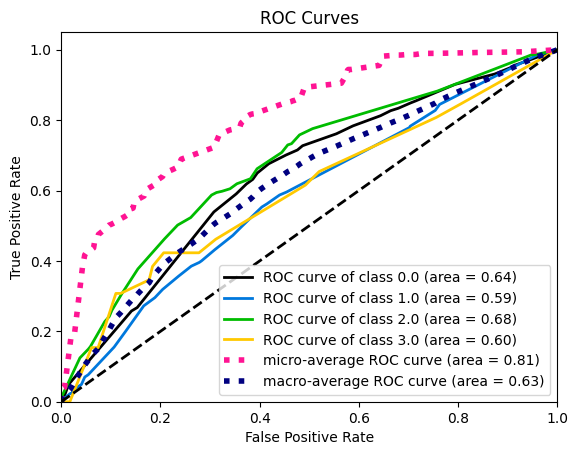

In [75]:
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()


### Cluster Centroids

In [76]:
from sklearn.cluster import MiniBatchKMeans
from imblearn.under_sampling import ClusterCentroids

In [77]:
cc = ClusterCentroids(
    estimator=MiniBatchKMeans(n_init=1, random_state=0), random_state=42
)
X_res, y_res = cc.fit_resample(X, y)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0.0: 85, 1.0: 85, 2.0: 85, 3.0: 85})


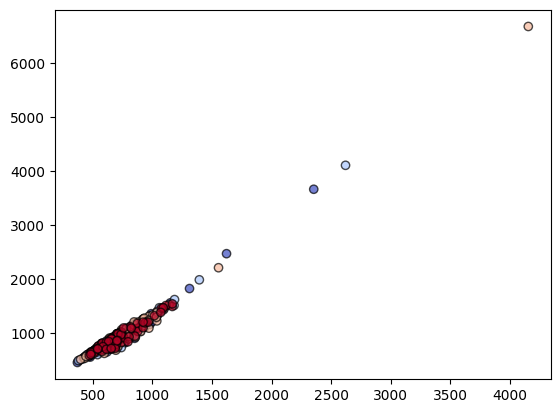

In [78]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [79]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.03, 'min_samples_leaf': 20, 'max_depth': 24, 'criterion': 'gini'}
  Best CV score     : 0.5132
  Tree depth        : 8
  Number of leaves  : 13
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.03, 'min_samples_leaf': 20, 'max_depth': 24, 'criterion': 'gini'}
0.513215780178294


Accuracy 0.010337972166998012
F1-score [0.         0.         0.         0.02046438]
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      1738
         1.0       0.00      0.00      0.00       470
         2.0       0.00      0.00      0.00       281
         3.0       0.01      1.00      0.02        26

    accuracy                           0.01      2515
   macro avg       0.00      0.25      0.01      2515
weighted avg       0.00      0.01      0.00      2515



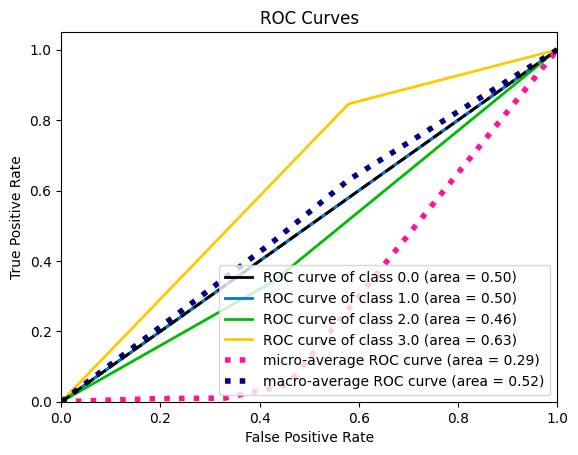

In [80]:
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()


# MIX

In [149]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [150]:
over_dic={1:2500,2:2000,3:1500}
under_dic={0:4000}

In [151]:
over = SMOTE(random_state=42, sampling_strategy=over_dic)
# under = ClusterCentroids(
#     estimator=MiniBatchKMeans(n_init=1, random_state=0), random_state=42,
#     sampling_strategy=under_dic
# )
#under = TomekLinks(sampling_strategy='majority')
under = RandomUnderSampler(random_state=42, sampling_strategy=under_dic)

#under = CondensedNearestNeighbour(random_state=42, n_jobs=10, sampling_strategy='majority')

## DECISION TREE

In [152]:
pipeline = Pipeline([
    ('over',  over),
    ('under', under),
    ('clf',   DecisionTreeClassifier())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [153]:
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.5188866799204771
F1-score [0.6867031  0.22868217 0.16932907 0.07692308]
              precision    recall  f1-score   support

         0.0       0.73      0.65      0.69      1738
         1.0       0.21      0.25      0.23       470
         2.0       0.15      0.19      0.17       281
         3.0       0.06      0.12      0.08        26

    accuracy                           0.52      2515
   macro avg       0.29      0.30      0.29      2515
weighted avg       0.56      0.52      0.54      2515



## DecisionTreeRandomSearch

In [154]:
from imblearn.pipeline import Pipeline          # ← key fix
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [155]:
# ── Before anything ───────────────────────────────────────────────────────────
print("="*50)
print("BEFORE RESAMPLING")
print("="*50)
for cls, count in sorted(Counter(y_train).items()):
    print(f"  Class {cls} : {count} samples")
print(f"  TOTAL    : {len(y_train)} samples")

BEFORE RESAMPLING
  Class 0.0 : 4056 samples
  Class 1.0 : 1097 samples
  Class 2.0 : 655 samples
  Class 3.0 : 59 samples
  TOTAL    : 5867 samples


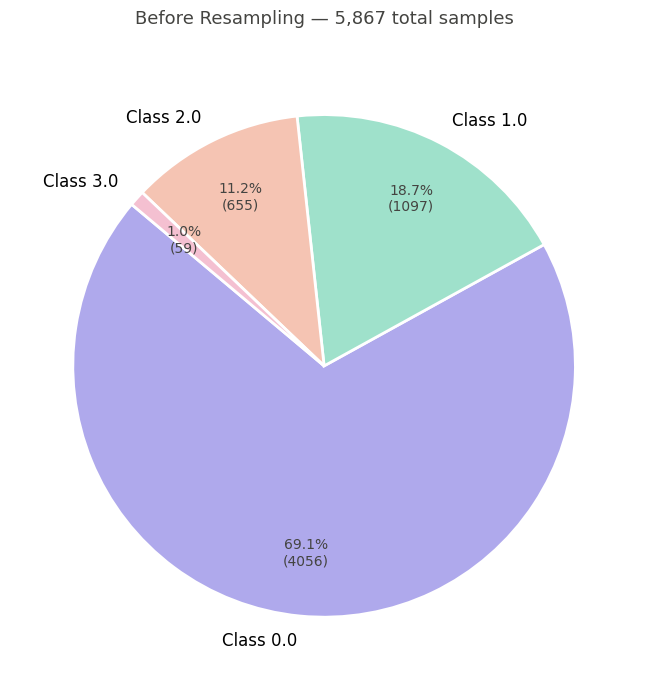

In [156]:
from collections import Counter
import matplotlib.pyplot as plt

# ── Before resampling ─────────────────────────────────────────────────────────
count   = Counter(y_train)
classes = [f"Class {cls}" for cls, _ in sorted(count.items())]
values  = [cnt for _, cnt in sorted(count.items())]
total   = len(y_train)

# ── Pastel colors ─────────────────────────────────────────────────────────────
colors = ['#AFA9EC', '#9FE1CB', '#F5C4B3', '#F4C0D1',
          '#B5D4F4', '#C0DD97', '#FAC775', '#F09595'][:len(classes)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    values,
    labels=classes,
    colors=colors,
    autopct=lambda p: f'{p:.1f}%\n({int(round(p * total / 100))})',
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2),
)

for text in texts:
    text.set_fontsize(12)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color('#444441')

ax.set_title(
    f"Before Resampling — {total:,} total samples",
    fontsize=13,
    pad=20,
    color='#444441'
)

plt.tight_layout()
plt.show()

In [157]:
# ── After SMOTE (over) ────────────────────────────────────────────────────────
X_temp, y_temp = over.fit_resample(X_train, y_train)

print("\n" + "="*50)
print("AFTER SMOTE (over-sampling)")
print("="*50)
for cls, count in sorted(Counter(y_temp).items()):
    print(f"  Class {cls} : {count} samples")
print(f"  TOTAL    : {len(y_temp)} samples")

# ── After ClusterCentroids (under) ────────────────────────────────────────────
X_temp2, y_temp2 = under.fit_resample(X_temp, y_temp)

print("\n" + "="*50)
print("AFTER Tomek links (under-sampling)")
print("="*50)
for cls, count in sorted(Counter(y_temp2).items()):
    print(f"  Class {cls} : {count} samples")
print(f"  TOTAL    : {len(y_temp2)} samples")


AFTER SMOTE (over-sampling)
  Class 0.0 : 4056 samples
  Class 1.0 : 2500 samples
  Class 2.0 : 2000 samples
  Class 3.0 : 1500 samples
  TOTAL    : 10056 samples

AFTER Tomek links (under-sampling)
  Class 0.0 : 4000 samples
  Class 1.0 : 2500 samples
  Class 2.0 : 2000 samples
  Class 3.0 : 1500 samples
  TOTAL    : 10000 samples


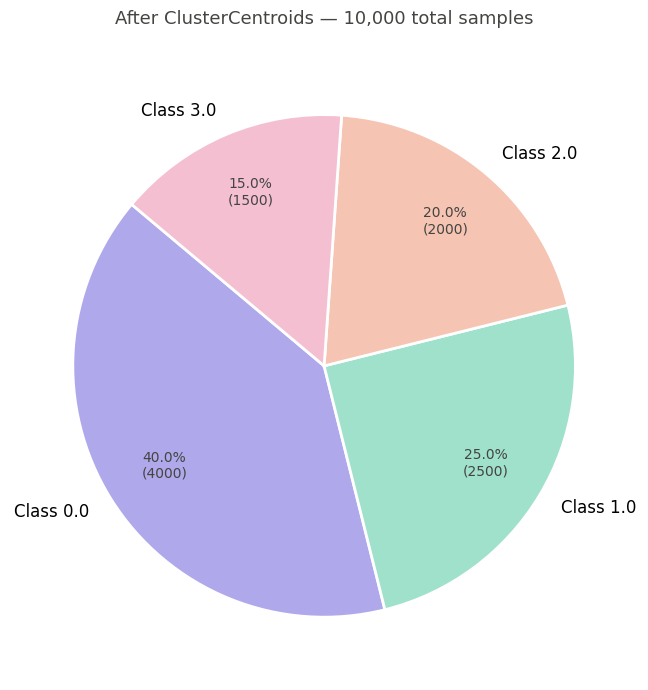

In [158]:
from collections import Counter
import matplotlib.pyplot as plt

# ── After ClusterCentroids (under) ───────────────────────────────────────────
X_temp2, y_temp2 = under.fit_resample(X_temp, y_temp)

count      = Counter(y_temp2)
classes    = [f"Class {cls}" for cls, _ in sorted(count.items())]
values     = [cnt for _, cnt in sorted(count.items())]
total      = len(y_temp2)

# ── Pastel colors ─────────────────────────────────────────────────────────────
colors = ['#AFA9EC', '#9FE1CB', '#F5C4B3', '#F4C0D1',
          '#B5D4F4', '#C0DD97', '#FAC775', '#F09595'][:len(classes)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    values,
    labels=classes,
    colors=colors,
    autopct=lambda p: f'{p:.1f}%\n({int(round(p * total / 100))})',
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2),
)

# ── Font styling ──────────────────────────────────────────────────────────────
for text in texts:
    text.set_fontsize(12)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color('#444441')

ax.set_title(
    f"After ClusterCentroids — {total:,} total samples",
    fontsize=13,
    pad=20,
    color='#444441'
)

plt.tight_layout()
plt.show()

In [159]:
# ─────────────────────────────────────────────────────────────
pipeline = Pipeline([
    ('over',  over),
    ('under', under),
    ('clf',   DecisionTreeRandomSearch(n_iter=400, n_splits=10, random_state=0))
])

pipeline.fit(X_train, y_train)
y_pred  = pipeline.predict(X_test)
y_score = pipeline.predict_proba(X_test)

DECISION TREE — TRAINING SUMMARY
  Best params   : {'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 35, 'criterion': 'gini'}
  Best CV score : 0.6201
  Tree depth    : 24
  Leaves        : 743


In [160]:
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.558648111332008
F1-score [0.73124461 0.17264574 0.18181818 0.07894737]
              precision    recall  f1-score   support

         0.0       0.73      0.73      0.73      1738
         1.0       0.18      0.16      0.17       470
         2.0       0.18      0.19      0.18       281
         3.0       0.06      0.12      0.08        26

    accuracy                           0.56      2515
   macro avg       0.29      0.30      0.29      2515
weighted avg       0.56      0.56      0.56      2515



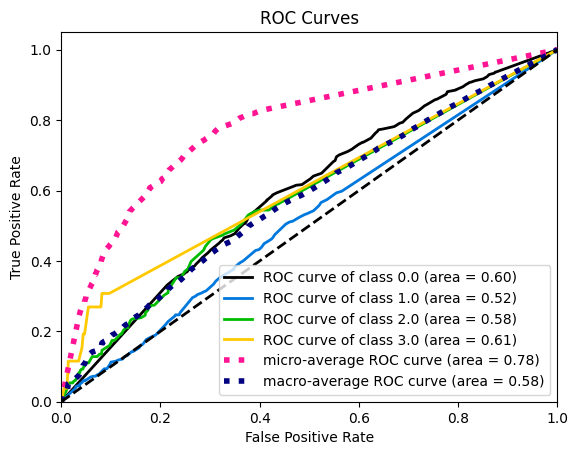

In [161]:
# roc
plot_roc(y_test, y_score)
plt.show()